In [1]:
import torch
from geodesic_toolbox import *
import matplotlib.pyplot as plt
import math

/home/tblanchard/phd/Finsler-Embedding/.venv/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
def sample_circle(n_pts:int=100):
    theta = torch.linspace(0, 2 * torch.pi, n_pts)
    x = torch.cos(theta)
    y = torch.sin(theta)
    return torch.stack((x, y), dim=1)

def indicatrix_riemann(x:torch.Tensor,cometric,n_pts:int=100):
    v = sample_circle(n_pts)
    v_norm = cometric.metric(x,v)
    v = v / v_norm.unsqueeze(-1)
    return v

def indicatrix_finsler(x:torch.Tensor,finsler:FinslerMetric,n_pts:int=100):
    v = sample_circle(n_pts)
    v_norm = finsler(x,v)
    v = v / v_norm.unsqueeze(-1)
    return v

def squarify(n:int):
    """Return the number of rows and columns to make a square grid of n points."""
    n_rows = int(math.ceil(math.sqrt(n)))
    n_cols = int(math.ceil(n / n_rows))
    return n_rows, n_cols

In [3]:
class ConstantCometric(CoMetric):
    def __init__(self):
        super().__init__()
        self.G = torch.eye(2)
        self.G[0, 0] = 1.0
        self.G[1, 1] = 1.0
        self.G[0, 1] = 0
        self.G[1, 0] = self.G[0, 1]

    def metric_tensor(self, x):
        return self.G.repeat(x.shape[0], 1, 1)
    
    def cometric_tensor(self, x):
        return torch.inverse(self.metric_tensor(x))

class ConstantOmega(torch.nn.Module):
    def __init__(self,cometric:CoMetric,norm:float=0.99):
        super().__init__()
        self.norm = norm
        self.omega = self.norm * torch.tensor([1.0, 0.0])

    def forward(self, x):
        omega_base = self.omega.repeat(x.shape[0], 1)
        omega_norm = cometric.cometric(x, omega_base)
        omega = omega_base / omega_norm.unsqueeze(-1)
        return omega


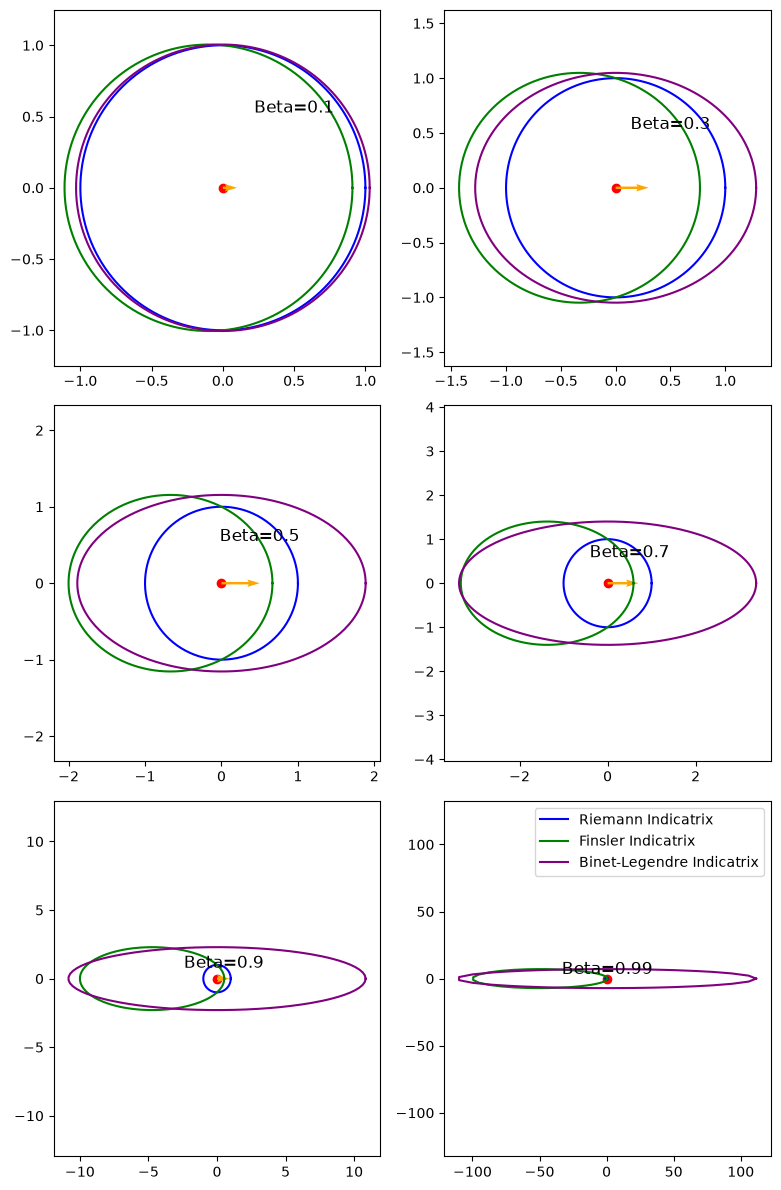

In [5]:
points = torch.zeros((1,2), dtype=torch.float64)

beta_list = [0.1, 0.3, 0.5, 0.7, 0.9, 0.99]
n_beta = len(beta_list)
n_rows, n_cols = squarify(n_beta)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*4))
for i,(ax,beta) in enumerate(zip(axes.flatten(), beta_list)):

    # cometric  = IdentityCoMetric()
    cometric = ConstantCometric()
    omega = ConstantOmega(cometric, norm=1.0)
    randers = RandersMetrics(cometric, omega,beta=beta)
    binet = BinetLegendreRanders(randers)

    v_riemann = indicatrix_riemann(points,cometric,300)
    v_riemann = points + v_riemann
    v_finsler = indicatrix_finsler(points,randers,300)
    v_finsler = points + v_finsler
    v_binet = indicatrix_riemann(points,binet,300)
    v_binet = points + v_binet

    omega_point = randers.omega(points) * randers.beta

    ax.plot(v_riemann[:,0],v_riemann[:,1],color='blue',label='Riemann Indicatrix')
    ax.plot(v_finsler[:,0],v_finsler[:,1],color='green',label='Finsler Indicatrix')
    ax.plot(v_binet[:,0],v_binet[:,1],color='purple',label='Binet-Legendre Indicatrix')
    ax.scatter(points[:,0],points[:,1],color='red')
    ax.quiver(points[:,0],points[:,1],omega_point[:,0],omega_point[:,1],color='orange',angles='xy', scale_units='xy', scale=1)
    ax.text(0.5, 0.5, f'Beta={beta}', fontsize=12, ha='center', va='bottom')
    ax.set_aspect('equal', adjustable='box')
    ax.axis('equal')
axes.flatten()[i].legend(loc='upper right')
for j in range(i+1, n_rows*n_cols):
    axes.flatten()[j].axis('off')
plt.tight_layout()
plt.show()